In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [11]:
df_DA_US = df_DA_US.explode('job_skills')

In [21]:
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_US_pay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)

df_DA_US_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

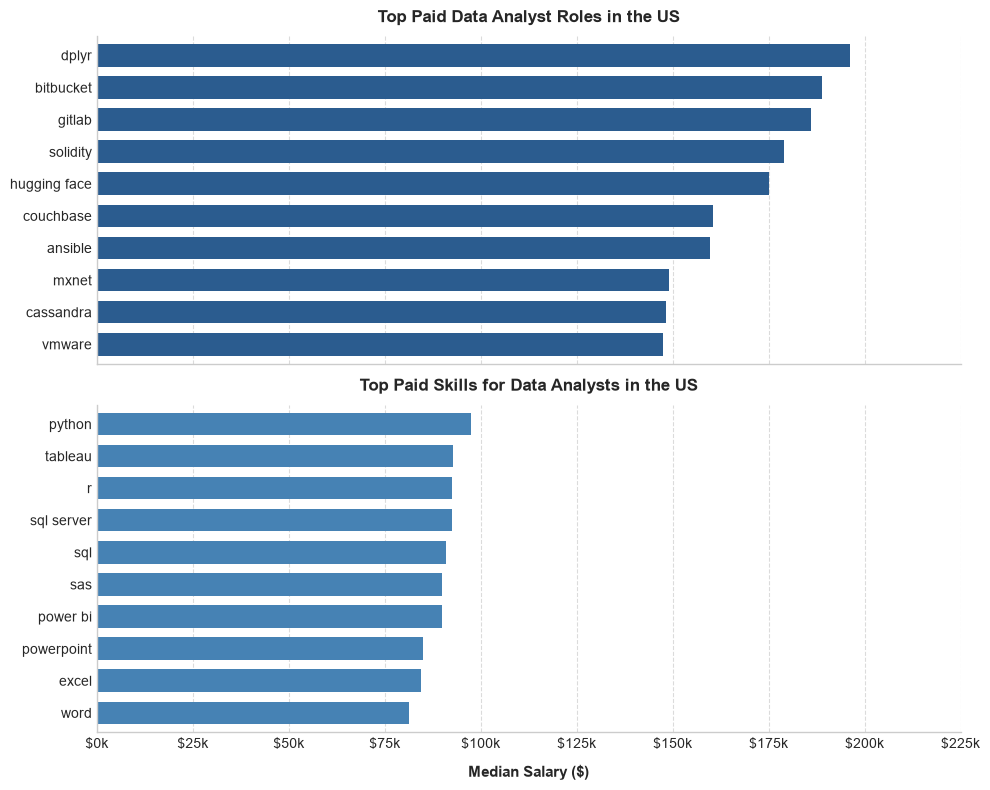

In [23]:
import matplotlib.pyplot as plt

# 1. Figure setup
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 2. Plotting bars
df_DA_US_pay[::-1].plot(
    kind='barh', 
    y='median', 
    ax=ax[0], 
    color='#2b5c8f', 
    legend=False, 
    width=0.7
)
df_DA_US_skills[::-1].plot(
    kind='barh', 
    y='median', 
    ax=ax[1], 
    color='#4682b4', 
    legend=False, 
    width=0.7
)

# 3. Titles & Labels
ax[0].set_title('Top Paid Data Analyst Roles in the US', fontsize=12, fontweight='bold', pad=10)
ax[1].set_title('Top Paid Skills for Data Analysts in the US', fontsize=12, fontweight='bold', pad=10)

ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($)', fontsize=11, fontweight='bold', labelpad=10)

# 4. Format X-axis tick labels directly without using ticker
plt.draw()  # Ensures ticks are computed
ticks = ax[1].get_xticks()
ax[1].set_xticks(ticks)
ax[1].set_xticklabels([f'${int(x/1000):,}k' for x in ticks])

# 5. Clean up borders & gridlines
for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.grid(axis='x', linestyle='--', alpha=0.7)
    a.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()